# fastdist release benchmarks

Reads the JSON reports under `benchmarks/results/` and renders the numbers behind
[`BENCHMARKS.md`](../BENCHMARKS.md). Nothing here is typed in by hand: every figure comes from a
recorded run, tagged with the commit and machine that produced it.

To measure your own machine first:

```bash
pip install scipy matplotlib
python benchmarks/run.py
```

## How to read these numbers

There are two baselines, and they answer different questions.

**vs `scipy.stats`** is what you would replace: `scipy.stats.norm.pdf(x, 0, 1)` and friends. fastdist
wins here by a wide margin, but most of that margin is SciPy's generic distribution machinery —
argument validation, broadcasting, masking — not faster arithmetic.

**vs primitives** is the honest ceiling: the same quantity written directly with numpy or
`scipy.special`, e.g. `scipy.special.ndtr(x)` for the normal CDF. Against that, fastdist is close to
parity, sometimes behind. If you are already writing vectorised numpy, this is the comparison that
matters to you.

Quote the first number and you will mislead someone. Both are shown below for every case.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

RESULTS = Path("..") / "benchmarks" / "results"
report_path = sorted(RESULTS.glob("*.json"))[-1]
report = json.loads(report_path.read_text(encoding="utf-8"))
env = report["environment"]
rows = report["results"]

print(f"report   {report_path.name}")
for key in ("fastdist_version", "git_commit", "timestamp_utc", "processor", "platform", "cuda_available"):
    print(f"{key:18} {env[key]}")
print(f"{'toolchain':18} python {env['python']}, numpy {env['numpy']}, scipy {env['scipy']}")

report   0.1.0_20260912T013406+0000_da5f274059.json
fastdist_version   0.1.0
git_commit         da5f274059956eb4a82cd491daa3a6383b89ac79
timestamp_utc      2026-09-12T01:34:06+00:00
processor          AMD Ryzen 7 7700 8-Core Processor
platform           Windows-11-10.0.26200-SP0
cuda_available     True
toolchain          python 3.14.2, numpy 2.5.2, scipy 1.18.1


## Both baselines, side by side

`speedup` above 1 means fastdist is faster. `max abs diff` is how far the two implementations
disagreed on the same input; the suite checks this before timing anything, because a speedup on a
wrong answer is not a speedup.

In [2]:
def by_group(group):
    return {(r["case"], r["n"]): r for r in rows if r["group"] == group}

batch, prims = by_group("batch"), by_group("primitives")
sizes = sorted({n for _, n in batch})

for n in sizes:
    print(f"\nn = {n:,}")
    print(f"  {'case':<18} {'fastdist':>10} {'vs scipy.stats':>15} {'vs primitives':>14} {'max abs diff':>13}")
    for case, size in sorted(batch):
        if size != n:
            continue
        b = batch[(case, n)]
        p = prims.get((case, n))
        prim = f"{p['speedup']:.2f}x" if p else "-"
        print(f"  {case:<18} {b['fastdist_s'] * 1e6:9.1f}us {b['speedup']:14.2f}x {prim:>14} {b['max_abs_diff']:13.1e}")


n = 1,000
  case                 fastdist  vs scipy.stats  vs primitives  max abs diff
  bernoulli_pmf            2.0us          24.77x          1.04x       2.2e-16
  exponential_cdf          4.5us           6.83x          1.04x       1.1e-16
  exponential_pdf          4.1us           7.22x          0.97x       0.0e+00
  normal_cdf               6.8us           4.50x          0.63x       2.2e-16
  normal_logpdf            1.9us          16.86x          0.97x       8.9e-16
  normal_pdf               5.2us           6.09x          0.88x       1.1e-16
  poisson_cdf              9.9us           7.12x          3.63x       2.2e-16
  poisson_pmf             40.7us           0.95x          0.37x       2.0e-19
  uniform_cdf              2.1us          15.19x          1.58x       0.0e+00
  uniform_pdf              2.0us          15.74x          1.41x       0.0e+00

n = 100,000
  case                 fastdist  vs scipy.stats  vs primitives  max abs diff
  bernoulli_pmf          290.9us          

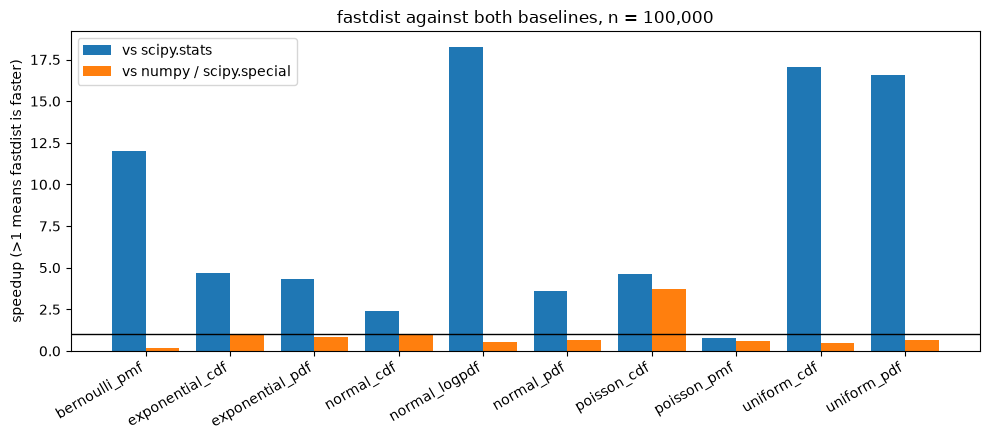

In [3]:
n = 100_000 if 100_000 in sizes else sizes[-1]
cases = sorted({c for c, size in batch if size == n and (c, n) in prims})

fig, ax = plt.subplots(figsize=(10, 4.5))
width = 0.4
positions = range(len(cases))
ax.bar([p - width / 2 for p in positions], [batch[(c, n)]["speedup"] for c in cases],
       width, label="vs scipy.stats")
ax.bar([p + width / 2 for p in positions], [prims[(c, n)]["speedup"] for c in cases],
       width, label="vs numpy / scipy.special")
ax.axhline(1.0, color="black", linewidth=1)
ax.set_xticks(list(positions))
ax.set_xticklabels(cases, rotation=30, ha="right")
ax.set_ylabel("speedup (>1 means fastdist is faster)")
ax.set_title(f"fastdist against both baselines, n = {n:,}")
ax.legend()
fig.tight_layout()
plt.show()

The gap between the two bars is the cost of SciPy's distribution layer, not a difference in the
mathematics. Where the second bar sits below 1, hand-written numpy beats this library.

In [4]:
cuda = by_group("cuda")
if not cuda:
    print("This report came from a CPU-only build, so there are no GPU numbers.")
else:
    print("GPU path against this library's own CPU path (>1 means the GPU wins)\n")
    print(f"  {'case':<18} {'n':>11} {'gpu':>10} {'cpu':>10} {'speedup':>9}")
    for case, n in sorted(cuda, key=lambda k: (k[1], k[0])):
        r = cuda[(case, n)]
        print(f"  {case:<18} {n:>11,} {r['fastdist_s'] * 1e6:9.1f}us {r['baseline_s'] * 1e6:9.1f}us"
              f" {r['speedup']:8.2f}x")
    print("\nThe GPU must be warmed before timing. An idle NVIDIA card drops its clocks and")
    print("downtrains its PCIe link, which made the same call measure 4.1x slower; run.py now")
    print("runs sustained GPU work first.")

GPU path against this library's own CPU path (>1 means the GPU wins)

  case                         n        gpu        cpu   speedup
  exponential_pdf          1,000      25.3us       4.3us     0.17x
  normal_cdf               1,000      22.8us       7.1us     0.31x
  normal_logpdf            1,000      28.5us       2.4us     0.08x
  normal_pdf               1,000      23.9us       6.7us     0.28x
  uniform_pdf              1,000      24.7us       2.3us     0.09x
  exponential_pdf        100,000     187.1us     313.5us     1.68x
  normal_cdf             100,000     210.3us     896.4us     4.26x
  normal_logpdf          100,000     201.4us      77.9us     0.39x
  normal_pdf             100,000     192.9us     420.0us     2.18x
  uniform_pdf            100,000     186.1us      94.5us     0.51x
  exponential_pdf      1,000,000    1884.9us    3745.5us     1.99x
  normal_cdf           1,000,000    2145.7us    9828.0us     4.58x
  normal_logpdf        1,000,000    1964.0us    1309.6us     

## Where this library is and is not the right tool

Read off the tables above rather than from memory, but as of this report:

- **Good fit:** evaluating PDFs/CDFs over arrays when you would otherwise call `scipy.stats`, and
  scalar calls in a Python loop, where fastdist's thinner binding layer is worth much more than the
  arithmetic.
- **No advantage:** against hand-written vectorised numpy, where the two are close and numpy
  sometimes wins.
- **Wrong tool:** bulk random sampling. Every variate crosses the Python/C++ boundary individually,
  so numpy is one to two orders of magnitude faster. See the `sample` group in the report.

Reproduce everything here with `python benchmarks/run.py`, compare two runs with
`python benchmarks/compare.py --latest`, and see `BENCHMARKS.md` for the full log.